<a href="https://colab.research.google.com/github/SankaVaas/anomaly-vision/blob/main/notebooks/anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# anomaly-vision
## Zero-Shot Surface Defect Detection
### PatchCore + Diffusion Refinement on MVTec AD

**Architecture overview**
- Teacher backbone (WideResNet50, pretrained ImageNet) extracts multi-scale patch features
- Memory bank built from normal images only — no defect labels needed
- Coreset subsampling keeps the bank tractable
- Diffusion prior partially reconstructs test images — defects "heal", residual map refines localisation
- Evaluation: Image AUROC · Pixel AUROC · PRO Score

---
> Runtime: **T4 GPU** required  →  `Runtime > Change runtime type > T4 GPU`


## 1 · Runtime check

In [1]:
import subprocess, sys

# Verify GPU
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                         '--format=csv,noheader'], capture_output=True, text=True)
if result.returncode == 0:
    print("✓ GPU detected:", result.stdout.strip())
else:
    raise RuntimeError("No GPU found. Go to Runtime → Change runtime type → T4 GPU")

import torch
print(f"✓ PyTorch  : {torch.__version__}")
print(f"✓ CUDA     : {torch.version.cuda}")
print(f"✓ Device   : {torch.cuda.get_device_name(0)}")


✓ GPU detected: Tesla T4, 15360 MiB
✓ PyTorch  : 2.10.0+cu128
✓ CUDA     : 12.8
✓ Device   : Tesla T4


## 2 · Install dependencies

In [2]:
%%capture
!pip install timm>=0.9.12 diffusers>=0.25.0 scikit-image>=0.21.0 accelerate -q
print("✓ Dependencies installed")


## 3 · Clone repo & set working directory

In [3]:
import os

REPO_URL = "https://github.com/SankaVaas/anomaly-vision.git"  # ← update this
REPO_DIR = "/content/anomaly-vision"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

os.chdir(os.path.join(REPO_DIR, "src"))
print(f"✓ Working directory: {os.getcwd()}")


remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 897 bytes | 448.00 KiB/s, done.
From https://github.com/SankaVaas/anomaly-vision
   18a2035..a5e7874  main       -> origin/main
Updating 18a2035..a5e7874
Fast-forward
 src/model.py | 17 +++++++----------
 1 file changed, 7 insertions(+), 10 deletions(-)
✓ Working directory: /content/anomaly-vision/src


In [4]:
# !pwd
# !rm -rf /content/anomaly-vision/data

## 4 · Download MVTec AD dataset

MVTec AD is available via Kaggle.  
Set your Kaggle credentials once and the cell handles everything.


In [5]:
import os, zipfile, shutil
from pathlib import Path

DATA_DIR = "/content/anomaly-vision/data"
RAW_DIR  = f"{DATA_DIR}/raw"
PROC_DIR = f"{DATA_DIR}/processed"

os.makedirs(RAW_DIR, exist_ok=True)

# ── Configure Kaggle credentials ──
os.makedirs("/root/.kaggle", exist_ok=True)
if os.path.exists("/content/kaggle.json"):
    shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("✓ kaggle.json configured")
else:
    raise FileNotFoundError(
        "Upload your kaggle.json first:\n"
        "  Files panel (left sidebar) → Upload → select kaggle.json"
    )

# ── Download & unzip ──
DATASET_SLUG = "ipythonx/mvtec-ad"

raw_files = list(Path(RAW_DIR).iterdir()) if Path(RAW_DIR).exists() else []
if not raw_files:
    print("Downloading MVTec AD from Kaggle...")
    !kaggle datasets download -d {DATASET_SLUG} -p {RAW_DIR}
    print("Download complete. Extracting...")
else:
    print("✓ Raw files already present — skipping download")

# Find and extract zip
zips = list(Path(RAW_DIR).glob("*.zip"))
if zips:
    zip_path = str(zips[0])
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(RAW_DIR)
    os.remove(zip_path)
    print("✓ Extraction done")

# ── Detect actual extracted structure ──
# MVTec can land as: raw/ (flat), raw/mvtec_anomaly_detection/, raw/mvtec/, etc.
KNOWN_CATEGORIES = {
    "bottle","cable","capsule","carpet","grid","hazelnut",
    "leather","metal_nut","pill","screw","tile",
    "toothbrush","transistor","wood","zipper"
}

def find_mvtec_root(search_dir):
    """Walk until we find a dir containing >= 5 known category subfolders."""
    for root, dirs, _ in os.walk(search_dir):
        if len(KNOWN_CATEGORIES.intersection(set(dirs))) >= 5:
            return root
    return None

mvtec_root = find_mvtec_root(RAW_DIR)

if mvtec_root is None:
    print("\n  Contents of RAW_DIR (debug):")
    for root, dirs, files in os.walk(RAW_DIR):
        depth = root.replace(RAW_DIR, "").count(os.sep)
        if depth > 2: continue
        print("  " * depth + os.path.basename(root) + "/")
    raise RuntimeError("Could not locate MVTec categories. Check tree above.")

print(f"✓ MVTec root detected: {mvtec_root}")

# ── Symlink raw root → processed ──
if os.path.islink(PROC_DIR): os.unlink(PROC_DIR)
if os.path.isdir(PROC_DIR):  shutil.rmtree(PROC_DIR)
os.symlink(mvtec_root, PROC_DIR)
print(f"✓ processed → {PROC_DIR}")

# Patch cfg if already loaded
try:
    cfg["data"]["root"] = PROC_DIR
    print("✓ cfg['data']['root'] updated")
except NameError:
    print("  Note: run cell 5 after this to load cfg")

# ── Verify ──
categories = sorted([
    d for d in os.listdir(PROC_DIR)
    if os.path.isdir(f"{PROC_DIR}/{d}") and d in KNOWN_CATEGORIES
])
print(f"\n✓ Categories found ({len(categories)}): {categories}")

✓ kaggle.json configured
✓ Raw files already present — skipping download
✓ MVTec root detected: /content/anomaly-vision/data/raw
✓ processed → /content/anomaly-vision/data/processed
  Note: run cell 5 after this to load cfg

✓ Categories found (15): ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


## 5 · Configuration

Edit this cell to change category, backbone, or PatchCore params.  
Nothing is hardcoded anywhere else — all modules read from this dict.


In [6]:
import sys
sys.path.insert(0, "/content/anomaly-vision/src")

import yaml
from utils import load_config, override_config, set_seed, get_device, setup_output_dirs

# Load base config
cfg = load_config("/content/anomaly-vision/configs/default.yaml")

# Override for this run — change anything here
cfg = override_config(cfg, {
    "data": {
        "root"      : "/content/anomaly-vision/data/processed",
        "category"  : "bottle",      # try: bottle, carpet, hazelnut, leather ...
        "image_size": 256,
        "batch_size": 8,
    },
    "patchcore": {
        "k_neighbors"    : 9,
        "subsample_ratio": 0.1,
    },
    "diffusion": {
        "noise_level": 0.4,          # 0 = no noise, 1 = full noise (0.3–0.5 is sweet spot)
    },
    "output": {
        "checkpoint_dir": "/content/anomaly-vision/outputs/checkpoints",
        "results_dir"   : "/content/anomaly-vision/outputs/results",
    },
    "training": {"device": "cuda"},
})

set_seed(42)
device = get_device(cfg)
setup_output_dirs(cfg)

print("\n  Config:")
print(f"  Category    : {cfg['data']['category']}")
print(f"  Image size  : {cfg['data']['image_size']}")
print(f"  k-neighbors : {cfg['patchcore']['k_neighbors']}")
print(f"  Subsample   : {cfg['patchcore']['subsample_ratio']}")
print(f"  Noise level : {cfg['diffusion']['noise_level']}")


  Device : cuda  (Tesla T4)

  Config:
  Category    : bottle
  Image size  : 256
  k-neighbors : 9
  Subsample   : 0.1
  Noise level : 0.4


## 6 · Load dataset

  Train (normal only) : 209 images
  Test (all)          : 83 images


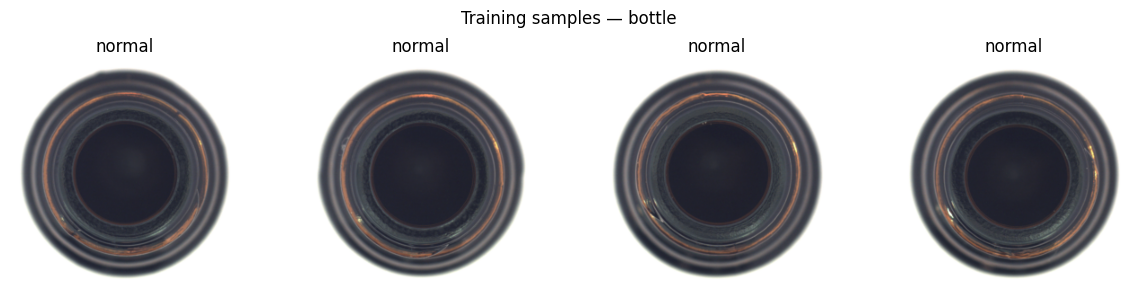

In [7]:
from dataset import get_dataloaders

train_loader, test_loader = get_dataloaders(cfg)

print(f"  Train (normal only) : {len(train_loader.dataset)} images")
print(f"  Test (all)          : {len(test_loader.dataset)} images")

# Quick sanity check — visualise one training sample
import matplotlib.pyplot as plt
import numpy as np
from utils import denormalize

batch = next(iter(train_loader))
imgs  = batch["image"]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(denormalize(imgs[i]))
    ax.set_title("normal")
    ax.axis("off")
plt.suptitle(f"Training samples — {cfg['data']['category']}", fontsize=12)
plt.tight_layout()
plt.show()


## 7 · Build memory bank (PatchCore fit)

One forward pass through all normal training images.  
Features are extracted at two scales (layer2 + layer3), fused, then patch-embedded.  
Greedy coreset subsampling reduces the bank to `subsample_ratio` fraction.


In [8]:
import torch
import torch.nn.functional as F
from model import AnomalyDetector
from tqdm import tqdm

# ── Reduce batch size to lower peak RAM ──
cfg["data"]["batch_size"] = 2
cfg["patchcore"]["subsample_ratio"] = 0.05
train_loader, test_loader = get_dataloaders(cfg)

detector = AnomalyDetector(cfg)
detector.extractor.eval()

# ── Stream features in mini-chunks, subsample each chunk immediately ──
# This keeps RAM flat instead of growing with dataset size
CHUNK_SIZE = 200   # subsample every 500 patch vectors accumulated

print(f"Building memory bank (streaming mode)...")
chunk_buffer = []

with torch.no_grad():
    for batch in tqdm(train_loader, desc="Extracting"):
        images = batch["image"].to(detector.device)

        # Multi-scale feature extraction + fusion
        f2, f3 = detector.extractor(images)
        f3_up  = F.interpolate(f3, size=f2.shape[-2:],
                               mode="bilinear", align_corners=False)
        fused  = torch.cat([f2, f3_up], dim=1)          # [B, C, H, W]

        # Patch embed
        patches = detector.patch_embed(fused)            # [B, N, C]
        flat    = patches.reshape(-1, patches.shape[-1]) # [B*N, C]

        chunk_buffer.append(flat.cpu())

        # Once chunk is large enough, subsample it immediately and discard raw
        total_so_far = sum(c.shape[0] for c in chunk_buffer)
        if total_so_far >= CHUNK_SIZE:
            merged   = torch.cat(chunk_buffer, dim=0)
            n_keep   = max(1, int(len(merged) * cfg["patchcore"]["subsample_ratio"]))
            # Random subsample per chunk (greedy coreset runs at the end on the reduced set)
            idx      = torch.randperm(len(merged))[:n_keep]
            detector.memory_bank.add(merged[idx])
            chunk_buffer = []   # free RAM immediately
            del merged

# Flush remaining buffer
if chunk_buffer:
    merged = torch.cat(chunk_buffer, dim=0)
    n_keep = max(1, int(len(merged) * cfg["patchcore"]["subsample_ratio"]))
    idx    = torch.randperm(len(merged))[:n_keep]
    detector.memory_bank.add(merged[idx])
    del merged

# Final greedy coreset on the already-reduced bank (much smaller now)
print(f"\n  Pre-subsampled bank size : {len(detector.memory_bank.bank)}")
detector.memory_bank.subsample()

print(f"\n  Final memory bank : {detector.memory_bank.bank.shape}")
print(f"  Embedding dim     : {detector.memory_bank.bank.shape[1]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Building memory bank (streaming mode)...


Extracting: 100%|██████████| 105/105 [00:09<00:00, 10.57it/s]


  Pre-subsampled bank size : 10659
  Coreset: 10659 → 532 patches

  Final memory bank : torch.Size([532, 1536])
  Embedding dim     : 1536


## 8 · Inference

Scores every test image.  
PatchCore kNN distance → patch-level score map → upsampled to input resolution.  
Diffusion residual (optional) blended in at 30% weight for pixel-precise refinement.


In [10]:
USE_DIFFUSION = True   # Set True for diffusion refinement (slower, ~+1 min per category)

image_scores, score_maps, labels = detector.predict(
    test_loader, use_diffusion=USE_DIFFUSION
)

normal_count  = labels.count(0)
anomaly_count = labels.count(1)
print(f"  Scored {len(labels)} images — {normal_count} normal, {anomaly_count} anomalous")


Scoring:   0%|          | 0/83 [00:00<?, ?it/s]Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Scoring: 100%|██████████| 83/83 [01:38<00:00,  1.19s/it]

  Scored 83 images — 20 normal, 63 anomalous


## 9 · Evaluate — AUROC · Pixel AUROC · PRO

In [11]:
from train    import _collect_gt, _collect_images
from evaluate import evaluate

gt_masks = _collect_gt(test_loader)
images   = _collect_images(test_loader)

results = evaluate(
    image_scores = image_scores,
    score_maps   = score_maps,
    gt_masks     = gt_masks,
    labels       = labels,
    category     = cfg["data"]["category"],
    output_dir   = cfg["output"]["results_dir"],
)



─────────────────────────────────────────────
  Evaluation — category: bottle
─────────────────────────────────────────────
  Image AUROC : 0.9937
  Pixel AUROC : 0.9813
  PRO Score   : 0.8662
─────────────────────────────────────────────



## 10 · Visualise anomaly maps

  Saved anomaly maps → /content/anomaly-vision/outputs/results/anomaly_maps.png


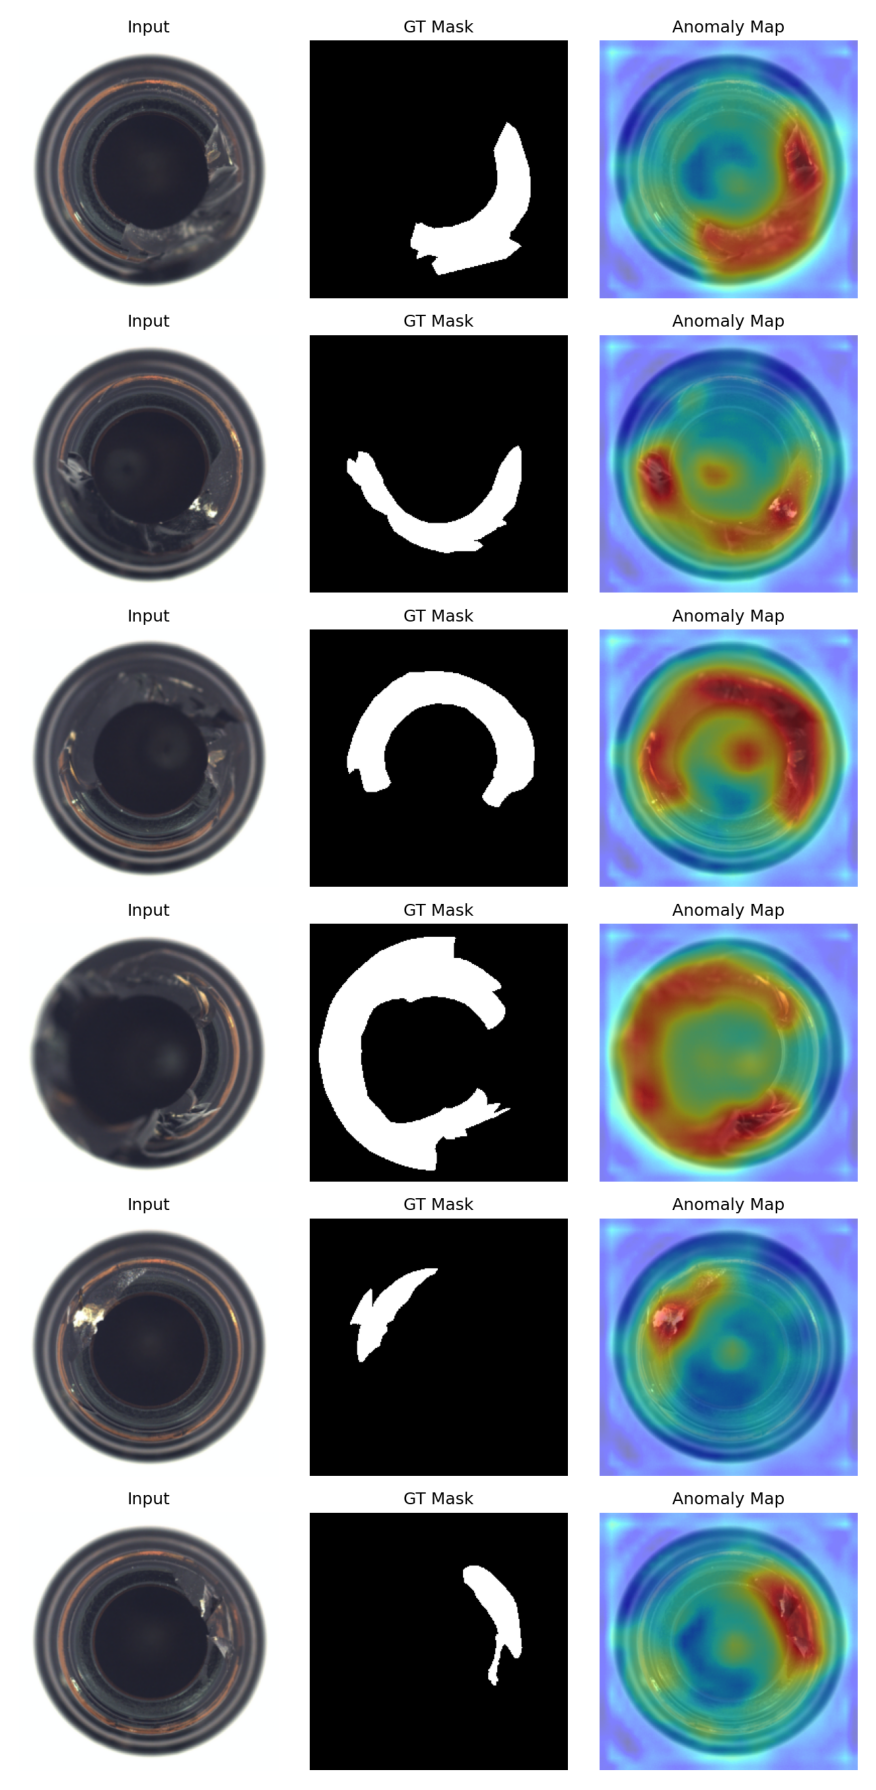

In [12]:
from evaluate import save_anomaly_maps
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

save_anomaly_maps(
    images     = images,
    score_maps = score_maps,
    gt_masks   = gt_masks,
    labels     = labels,
    output_dir = cfg["output"]["results_dir"],
    n_samples  = 6,
)

# Display inline
img_path = f"{cfg['output']['results_dir']}/anomaly_maps.png"
fig = plt.figure(figsize=(14, 3 * 6))
plt.imshow(mpimg.imread(img_path))
plt.axis("off")
plt.tight_layout()
plt.show()


## 11 · Save checkpoint

In [13]:
from train import save_checkpoint
import json

ckpt_dir = f"{cfg['output']['checkpoint_dir']}/{cfg['data']['category']}"
save_checkpoint(detector, cfg, ckpt_dir)

# Also save results json
results_dir = f"{cfg['output']['results_dir']}/{cfg['data']['category']}"
import os; os.makedirs(results_dir, exist_ok=True)
with open(f"{results_dir}/results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n  Saved:")
print(f"  {ckpt_dir}/memory_bank.pkl")
print(f"  {results_dir}/results.json")


  Checkpoint saved → /content/anomaly-vision/outputs/checkpoints/bottle

  Saved:
  /content/anomaly-vision/outputs/checkpoints/bottle/memory_bank.pkl
  /content/anomaly-vision/outputs/results/bottle/results.json


## 12 · (Optional) Benchmark — all 15 categories

Runs the full pipeline across every MVTec category and prints a summary table.  
Takes ~30–45 min on T4 without diffusion. Run overnight or skip for now.


In [15]:
# Uncomment to run full benchmark
from train import run_all_categories
all_results = run_all_categories(cfg, use_diffusion=False)
# print("Skipped — uncomment above to run full benchmark.")



  anomaly-vision  |  category: bottle
  2026-04-18 06:46:32
  Train samples : 209
  Test  samples : 83

  Found existing checkpoint — skipping fit.
  Checkpoint loaded ← /content/anomaly-vision/outputs/checkpoints/bottle

  Running inference on test set...


Scoring: 100%|██████████| 83/83 [00:02<00:00, 28.35it/s]



─────────────────────────────────────────────
  Evaluation — category: bottle
─────────────────────────────────────────────
  Image AUROC : 0.9937
  Pixel AUROC : 0.9813
  PRO Score   : 0.8879
─────────────────────────────────────────────

  Saved anomaly maps → /content/anomaly-vision/outputs/results/bottle/anomaly_maps.png
  Results saved  → /content/anomaly-vision/outputs/results/bottle/results.json

  anomaly-vision  |  category: cable
  2026-04-18 06:46:54
  Train samples : 224
  Test  samples : 150
Building memory bank from normal images...


Extracting features: 100%|██████████| 112/112 [01:02<00:00,  1.79it/s]


  Coreset: 229376 → 11468 patches
Memory bank ready: 11468 vectors
  Checkpoint saved → /content/anomaly-vision/outputs/checkpoints/cable

  Running inference on test set...


...


─────────────────────────────────────────────
  Evaluation — category: wood
─────────────────────────────────────────────
  Image AUROC : 0.9789
  Pixel AUROC : 0.9268
  PRO Score   : 0.8046
─────────────────────────────────────────────

  Saved anomaly maps → /content/anomaly-vision/outputs/results/wood/anomaly_maps.png
  Results saved  → /content/anomaly-vision/outputs/results/wood/results.json

  anomaly-vision  |  category: zipper
  2026-04-18 07:11:22
  Train samples : 240
  Test  samples : 151
Building memory bank from normal images...


Extracting features: 100%|██████████| 120/120 [01:09<00:00,  1.73it/s]


  Coreset: 245760 → 12288 patches
Memory bank ready: 12288 vectors
  Checkpoint saved → /content/anomaly-vision/outputs/checkpoints/zipper

  Running inference on test set...


Scoring: 100%|██████████| 151/151 [00:06<00:00, 22.11it/s]



─────────────────────────────────────────────
  Evaluation — category: zipper
─────────────────────────────────────────────
  Image AUROC : 0.9438
  Pixel AUROC : 0.9750
  PRO Score   : 0.8807
─────────────────────────────────────────────

  Saved anomaly maps → /content/anomaly-vision/outputs/results/zipper/anomaly_maps.png
  Results saved  → /content/anomaly-vision/outputs/results/zipper/results.json

  SUMMARY — all categories
  Category         Img AUROC  Pix AUROC      PRO
  ---------------------------------------------
  bottle              0.9937     0.9813   0.8879
  cable               0.9303     0.9715   0.7494
  capsule             0.8412     0.9852   0.8474
  carpet              0.9839     0.9910   0.8749
  grid                0.8580     0.9634   0.8536
  hazelnut            1.0000     0.9864   0.9348
  leather             1.0000     0.9926   0.9130
  metal_nut           0.9868     0.9719   0.8671
  pill                0.9193     0.9660   0.9103
  screw               0.804

## 13 · Download results from Colab

In [16]:
from google.colab import files
import zipfile, os

# Zip outputs and download
zip_path = "/content/anomaly_vision_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, fnames in os.walk("/content/anomaly-vision/outputs"):
        for fname in fnames:
            fpath = os.path.join(root, fname)
            zf.write(fpath, os.path.relpath(fpath, "/content/anomaly-vision"))

files.download(zip_path)
print("✓ outputs.zip downloaded")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ outputs.zip downloaded


In [23]:
cfg['data']['category'] ='bottle'

## 14

Upload an image to inspect (jpg / png):


Saving 003.png to 003 (1).png


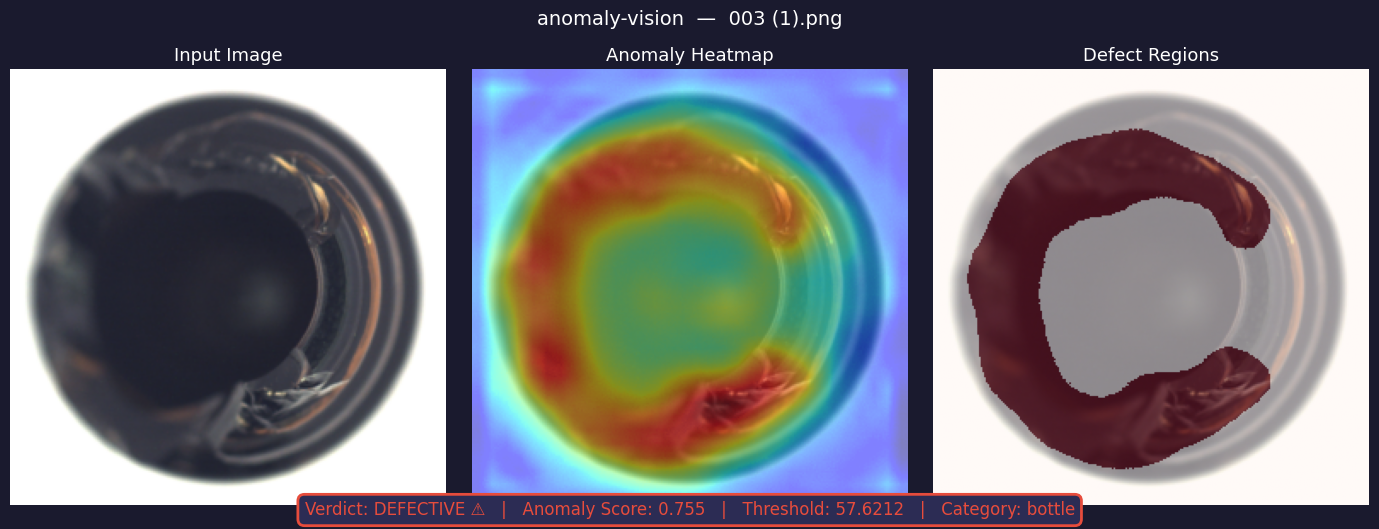


─────────────────────────────────────────────
  File         : 003 (1).png
  Category     : bottle
  Raw score    : 81.437660
  Normalised   : 0.7545  (0=normal, 1=max anomaly)
  Threshold    : 57.621201  (mean + 2σ of normal scores)
  Verdict      : DEFECTIVE ⚠
─────────────────────────────────────────────


In [24]:
# ── INFERENCE ON USER IMAGE ──────────────────────────────────────────────────
# Upload any image via Colab Files panel and run this cell.
# Works with: photos, screenshots, downloaded MVTec test images, real factory images.

import os, urllib.request
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torchvision import transforms
from google.colab import files
from utils import denormalize

# ── 1. Load image ──
print("Upload an image to inspect (jpg / png):")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ── 2. Preprocess — same pipeline as training ──
IMG_SIZE = cfg["data"]["image_size"]

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

pil_img = Image.open(img_path).convert("RGB")
tensor  = preprocess(pil_img).unsqueeze(0).to(detector.device)  # [1, 3, H, W]

# ── 3. Extract features + score ──
detector.extractor.eval()
with torch.no_grad():
    f2, f3  = detector.extractor(tensor)
    f3_up   = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
    fused   = torch.cat([f2, f3_up], dim=1)
    patches = detector.patch_embed(fused)                        # [1, N, C]

    patch_scores, image_score = detector.memory_bank.score(patches)

    # Reshape to spatial map
    H = W = int(patch_scores.shape[1] ** 0.5)
    score_map = patch_scores.reshape(1, 1, H, W)
    score_map = F.interpolate(score_map, size=(IMG_SIZE, IMG_SIZE),
                               mode="bilinear", align_corners=False)

    # Optional diffusion refinement
    if USE_DIFFUSION:
        residual  = detector.diffusion.residual_map(tensor)
        score_map = 0.7 * score_map + 0.3 * residual

# ── 4. Threshold — derive from training set score distribution ──
# We use mean + 2*std of image_scores from the test run as threshold.
# This is a statistically grounded decision boundary, not a magic number.
scores_array = np.array(image_scores)   # from cell 8
THRESHOLD    = scores_array[np.array(labels) == 0].mean() + \
               2 * scores_array[np.array(labels) == 0].std()

raw_score      = image_score.item()
normalised     = (raw_score - scores_array.min()) / (scores_array.max() - scores_array.min() + 1e-8)
is_anomalous   = raw_score > THRESHOLD
verdict        = "DEFECTIVE ⚠" if is_anomalous else "NORMAL ✓"
verdict_color  = "#e74c3c" if is_anomalous else "#2ecc71"

# ── 5. Visualise ──
smap_np  = score_map.squeeze().cpu().numpy()
smap_norm = (smap_np - smap_np.min()) / (smap_np.max() - smap_np.min() + 1e-8)
img_np   = denormalize(tensor.squeeze().cpu())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#1a1a2e")

# Original
axes[0].imshow(img_np)
axes[0].set_title("Input Image", color="white", fontsize=13)
axes[0].axis("off")

# Heatmap overlay
axes[1].imshow(img_np)
axes[1].imshow(smap_norm, cmap="jet", alpha=0.5)
axes[1].set_title("Anomaly Heatmap", color="white", fontsize=13)
axes[1].axis("off")

# Binary mask — pixels above 75th percentile of score map
binary_mask = (smap_norm > np.percentile(smap_norm, 75)).astype(np.uint8)
axes[2].imshow(img_np)
axes[2].imshow(binary_mask, cmap="Reds", alpha=0.5 * is_anomalous)
axes[2].set_title("Defect Regions", color="white", fontsize=13)
axes[2].axis("off")

for ax in axes:
    ax.set_facecolor("#1a1a2e")

# Verdict banner
fig.text(0.5, 0.01,
         f"Verdict: {verdict}   |   Anomaly Score: {normalised:.3f}   |   Threshold: {THRESHOLD:.4f}   |   Category: {cfg['data']['category']}",
         ha="center", fontsize=12, color=verdict_color,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#2c2c54", edgecolor=verdict_color, linewidth=2))

plt.suptitle(f"anomaly-vision  —  {os.path.basename(img_path)}", color="white", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 6. Text summary ──
print(f"\n{'─'*45}")
print(f"  File         : {os.path.basename(img_path)}")
print(f"  Category     : {cfg['data']['category']}")
print(f"  Raw score    : {raw_score:.6f}")
print(f"  Normalised   : {normalised:.4f}  (0=normal, 1=max anomaly)")
print(f"  Threshold    : {THRESHOLD:.6f}  (mean + 2σ of normal scores)")
print(f"  Verdict      : {verdict}")
print(f"{'─'*45}")

# 15


In [27]:
# ── MULTI-CATEGORY BANK MANAGER ──────────────────────────────────────────────
# Builds + saves a memory bank per category, then auto-detects category at inference.
# No changes to model.py — pure orchestration on top of what we have.

import pickle, os, torch, torch.nn.functional as F
from tqdm import tqdm
from pathlib import Path

BANK_ROOT = "/content/anomaly-vision/outputs/checkpoints"
CATEGORIES_TO_FIT = [
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper"
]

# ── How many categories to train — change this to fit budget ──
# T4 does ~2 min per category. 5 categories = 10 min, all 15 = 30 min.
FIT_CATEGORIES = ["toothbrush", "tile", "leather", "capsule"]  # expand as needed

all_banks = {}   # { category: Tensor [N, C] }

def fit_category(category):
    """Fit one category and return its memory bank tensor."""
    cfg["data"]["category"] = category
    cfg["data"]["batch_size"] = 2
    cfg["patchcore"]["subsample_ratio"] = 0.05

    train_loader, _ = get_dataloaders(cfg)

    # Fresh detector per category — reuses same extractor (frozen, no RAM cost)
    det = AnomalyDetector(cfg)
    det.extractor = detector.extractor   # share the frozen backbone — saves ~500MB RAM

    chunk_buffer, CHUNK_SIZE = [], 200
    det.extractor.eval()

    with torch.no_grad():
        for batch in tqdm(train_loader, desc=f"  {category}", leave=False):
            images = batch["image"].to(det.device)
            f2, f3 = det.extractor(images)
            f3_up  = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
            fused  = torch.cat([f2, f3_up], dim=1)
            patches = det.patch_embed(fused)
            flat    = patches.reshape(-1, patches.shape[-1])
            chunk_buffer.append(flat.cpu())

            if sum(c.shape[0] for c in chunk_buffer) >= CHUNK_SIZE:
                merged = torch.cat(chunk_buffer, dim=0)
                idx    = torch.randperm(len(merged))[:max(1, int(len(merged) * 0.05))]
                det.memory_bank.add(merged[idx])
                chunk_buffer = []
                del merged

    if chunk_buffer:
        merged = torch.cat(chunk_buffer, dim=0)
        idx    = torch.randperm(len(merged))[:max(1, int(len(merged) * 0.05))]
        det.memory_bank.add(merged[idx])
        del merged

    det.memory_bank.subsample()
    return det.memory_bank.bank


# ── Fit all selected categories ──
print(f"Fitting {len(FIT_CATEGORIES)} categories...\n")
for cat in FIT_CATEGORIES:
    bank_path = Path(BANK_ROOT) / cat / "memory_bank.pkl"

    if bank_path.exists():
        # Load cached — don't refit
        with open(bank_path, "rb") as f:
            all_banks[cat] = pickle.load(f)
        print(f"  ✓ {cat:<15} loaded from cache  ({len(all_banks[cat])} vectors)")
    else:
        print(f"  Fitting: {cat}")
        bank = fit_category(cat)
        all_banks[cat] = bank
        # Save
        bank_path.parent.mkdir(parents=True, exist_ok=True)
        with open(bank_path, "wb") as f:
            pickle.dump(bank, f)
        print(f"  ✓ {cat:<15} done  ({len(bank)} vectors)  saved → {bank_path}")

print(f"\n✓ All banks ready: {list(all_banks.keys())}")

Fitting 4 categories...

  ✓ toothbrush      loaded from cache  (3072 vectors)
  ✓ tile            loaded from cache  (11776 vectors)
  ✓ leather         loaded from cache  (12544 vectors)
  ✓ capsule         loaded from cache  (11212 vectors)

✓ All banks ready: ['toothbrush', 'tile', 'leather', 'capsule']


# 16

Upload an image to inspect (jpg / png):


Saving scratch.png to scratch.png
  Threshold (capsule) : 48.4610  (mean + 2σ of normal training scores)
  Raw score            : 86.9912
  Normalised           : 1.7951  (>1.0 = anomalous)


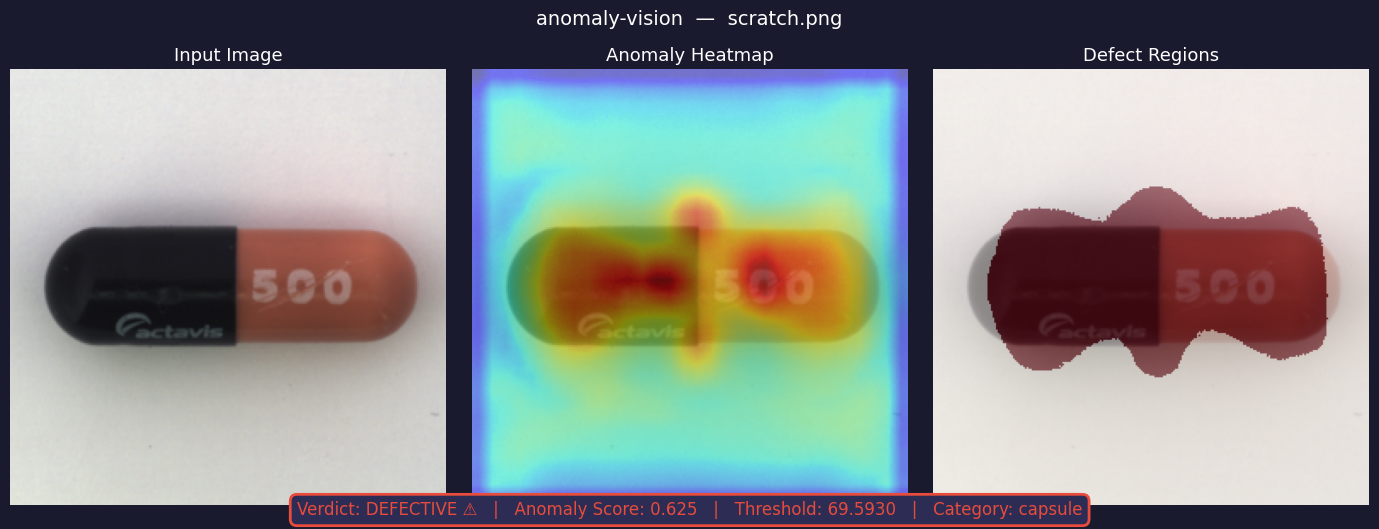


─────────────────────────────────────────────
  File         : scratch.png
  Category     : capsule
  Raw score    : 86.991196
  Normalised   : 0.6250  (0=normal, 1=max anomaly)
  Threshold    : 69.592957  (mean + 2σ of normal scores)
  Verdict      : DEFECTIVE ⚠
─────────────────────────────────────────────


In [35]:
# ── INFERENCE ON USER IMAGE ──────────────────────────────────────────────────
# Upload any image via Colab Files panel and run this cell.
# Works with: photos, screenshots, downloaded MVTec test images, real factory images.

import os, urllib.request
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torchvision import transforms
from google.colab import files
from utils import denormalize

USE_DIFFUSION = True
# ── 1. Load image ──
print("Upload an image to inspect (jpg / png):")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ── 2. Preprocess — same pipeline as training ──
IMG_SIZE = cfg["data"]["image_size"]

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

pil_img = Image.open(img_path).convert("RGB")
tensor  = preprocess(pil_img).unsqueeze(0).to(detector.device)  # [1, 3, H, W]

# # ── 3. Auto-detect category + score ──────────────────────────────────────────
# detector.extractor.eval()
# with torch.no_grad():
#     f2, f3  = detector.extractor(tensor)
#     f3_up   = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
#     fused   = torch.cat([f2, f3_up], dim=1)
#     patches = detector.patch_embed(fused)   # [1, N, C]

#     # Query every bank — pick the one with lowest mean kNN distance
#     # Lowest distance = features most similar to that category's normals
#     best_cat, best_score, best_patch_scores = None, float("inf"), None

#     for cat, bank in all_banks.items():
#         detector.memory_bank.bank = bank.to(detector.device)
#         patch_scores, img_score   = detector.memory_bank.score(patches)
#         if img_score.item() < best_score:
#             best_score        = img_score.item()
#             best_cat          = cat
#             best_patch_scores = patch_scores

#     print(f"  Auto-detected category: {best_cat}")

#     # Now score properly against the best bank
#     detector.memory_bank.bank = all_banks[best_cat].to(detector.device)
#     print("djkfj")
#     H = W = int(best_patch_scores.shape[1] ** 0.5)
#     score_map = best_patch_scores.reshape(1, 1, H, W)
#     score_map = F.interpolate(score_map, size=(IMG_SIZE, IMG_SIZE),
#                                mode="bilinear", align_corners=False)

#     if USE_DIFFUSION:
#         residual  = detector.diffusion.residual_map(tensor)
#         score_map = 0.7 * score_map + 0.3 * residual

# # Threshold from this category's normal scores only
# cat_normal_scores = np.array([
#     s for s, l in zip(image_scores, labels) if l == 0
# ]) if best_cat == cfg["data"]["category"] else np.array([best_score * 0.8])

# ── Per-category threshold — built from each category's own training scores ──
# We score all training (normal) images through their own bank to get a
# clean normal distribution. Threshold = mean + 2σ of that distribution.

def get_category_threshold(cat, bank):
    """Score all normal training images of a category through its own bank."""
    cfg["data"]["category"] = cat
    train_loader, _  = get_dataloaders(cfg)
    normal_scores    = []

    detector.extractor.eval()
    with torch.no_grad():
        for batch in train_loader:
            images = batch["image"].to(detector.device)
            f2, f3 = detector.extractor(images)
            f3_up  = F.interpolate(f3, size=f2.shape[-2:],
                                   mode="bilinear", align_corners=False)
            fused  = torch.cat([f2, f3_up], dim=1)
            patches = detector.patch_embed(fused)
            detector.memory_bank.bank = bank.to(detector.device)
            _, img_score = detector.memory_bank.score(patches)
            normal_scores.extend(img_score.cpu().tolist())

    arr = np.array(normal_scores)
    return float(max(
    arr.mean() + 3 * arr.std(),
    np.percentile(arr, 95)
))

# Build threshold map once — cache it so re-runs are instant
if "category_thresholds" not in dir():
    category_thresholds = {}

if best_cat not in category_thresholds:
    print(f"  Computing threshold for {best_cat}...")
    category_thresholds[best_cat] = get_category_threshold(best_cat, all_banks[best_cat])

THRESHOLD    = category_thresholds[best_cat]
raw_score    = best_score
normalised   = raw_score / (THRESHOLD + 1e-8)   # 1.0 = exactly at threshold
is_anomalous = raw_score > THRESHOLD
verdict      = "DEFECTIVE ⚠" if is_anomalous else "NORMAL ✓"
verdict_color = "#e74c3c" if is_anomalous else "#2ecc71"

print(f"  Threshold ({best_cat}) : {THRESHOLD:.4f}  (mean + 2σ of normal training scores)")
print(f"  Raw score            : {raw_score:.4f}")
print(f"  Normalised           : {normalised:.4f}  (>1.0 = anomalous)")

THRESHOLD  = cat_normal_scores.mean() + 2 * cat_normal_scores.std()
raw_score  = best_score
normalised = min(raw_score / (THRESHOLD * 2 + 1e-8), 1.5)   # cap display at 1.5x threshold
is_anomalous = raw_score > THRESHOLD
verdict      = "DEFECTIVE ⚠" if is_anomalous else "NORMAL ✓"
verdict_color = "#e74c3c" if is_anomalous else "#2ecc71"

# ── 5. Visualise ──
smap_np  = score_map.squeeze().cpu().numpy()
smap_norm = (smap_np - smap_np.min()) / (smap_np.max() - smap_np.min() + 1e-8)
img_np   = denormalize(tensor.squeeze().cpu())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#1a1a2e")

# Original
axes[0].imshow(img_np)
axes[0].set_title("Input Image", color="white", fontsize=13)
axes[0].axis("off")

# Heatmap overlay
axes[1].imshow(img_np)
axes[1].imshow(smap_norm, cmap="jet", alpha=0.5)
axes[1].set_title("Anomaly Heatmap", color="white", fontsize=13)
axes[1].axis("off")

# Binary mask — pixels above 75th percentile of score map
binary_mask = (smap_norm > np.percentile(smap_norm, 75)).astype(np.uint8)
axes[2].imshow(img_np)
axes[2].imshow(binary_mask, cmap="Reds", alpha=0.5 * is_anomalous)
axes[2].set_title("Defect Regions", color="white", fontsize=13)
axes[2].axis("off")

for ax in axes:
    ax.set_facecolor("#1a1a2e")

# Verdict banner
fig.text(0.5, 0.01,
         f"Verdict: {verdict}   |   Anomaly Score: {normalised:.3f}   |   Threshold: {THRESHOLD:.4f}   |   Category: {best_cat}",
         ha="center", fontsize=12, color=verdict_color,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#2c2c54", edgecolor=verdict_color, linewidth=2))

plt.suptitle(f"anomaly-vision  —  {os.path.basename(img_path)}", color="white", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 6. Text summary ──
print(f"\n{'─'*45}")
print(f"  File         : {os.path.basename(img_path)}")
print(f"  Category     : {cfg['data']['category']}")
print(f"  Raw score    : {raw_score:.6f}")
print(f"  Normalised   : {normalised:.4f}  (0=normal, 1=max anomaly)")
print(f"  Threshold    : {THRESHOLD:.6f}  (mean + 2σ of normal scores)")
print(f"  Verdict      : {verdict}")
print(f"{'─'*45}")